## 1. Carga de datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random

In [2]:
path = '/Users/alberth/Documents/Proyectos/data_cdt.xlsx'
df = pd.read_excel(path, sheet_name='Base')
df.head()

,ID,edad,Ocupación,estado civil,Nivel educativo,Default -Mora,Ingresos,Egresos,Saldo Depósitos,Saldo Colocacion,...,Tenencia Vivienda,Tenencia Libre inversión,Contacto,día,Mes,Duración,Contactos _Campaña,Dias_posteriores,Resultado campaña,Tenencia CDT
0,26110,56,Administrativo,Casado,Sin información,No,3280.360862,3051.831513,1933,97679.0,...,no,no,Telefono Fijo,19,nov,44,2,1,Sin informacion,no
1,40576,31,Sin información,Casado,Pregrado,No,3204.246501,2893.332815,3,57402.0,...,no,no,celular,20,jul,91,2,1,Sin informacion,no
2,15320,27,Servicio,Casado,Pregrado,No,-1413.998367,121.506093,891,99091.0,...,Si,no,celular,18,jul,240,1,1,Sin informacion,no
3,43962,57,Gerente,Separado,Posgrado,No,4761.027897,3857.669532,3287,61662.0,...,no,no,celular,22,jun,867,1,84,Éxito,Si
4,29842,31,Tecnico,Casado,Pregrado,No,4458.137900,3612.648245,119,96809.0,...,Si,no,celular,4,feb,380,1,1,Sin informacion,no


Ajustamos los nombres de las variables

In [3]:
df.columns = df.columns.str.lower().str.strip().str.replace(' ','_')
df = df.rename(columns={'default_-mora':'default_mora','contactos__campaña':'contactos_campaña'})
df.head()

,id,edad,ocupación,estado_civil,nivel_educativo,default_mora,ingresos,egresos,saldo_depósitos,saldo_colocacion,...,tenencia_vivienda,tenencia_libre_inversión,contacto,día,mes,duración,contactos_campaña,dias_posteriores,resultado_campaña,tenencia_cdt
0,26110,56,Administrativo,Casado,Sin información,No,3280.360862,3051.831513,1933,97679.0,...,no,no,Telefono Fijo,19,nov,44,2,1,Sin informacion,no
1,40576,31,Sin información,Casado,Pregrado,No,3204.246501,2893.332815,3,57402.0,...,no,no,celular,20,jul,91,2,1,Sin informacion,no
2,15320,27,Servicio,Casado,Pregrado,No,-1413.998367,121.506093,891,99091.0,...,Si,no,celular,18,jul,240,1,1,Sin informacion,no
3,43962,57,Gerente,Separado,Posgrado,No,4761.027897,3857.669532,3287,61662.0,...,no,no,celular,22,jun,867,1,84,Éxito,Si
4,29842,31,Tecnico,Casado,Pregrado,No,4458.137900,3612.648245,119,96809.0,...,Si,no,celular,4,feb,380,1,1,Sin informacion,no


## 2. Análisis exploratorio de datos

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 31647 entries, 0 to 31646
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        31647 non-null  int64  
 1   edad                      31647 non-null  int64  
 2   ocupación                 31647 non-null  str    
 3   estado_civil              31647 non-null  str    
 4   nivel_educativo           31647 non-null  str    
 5   default_mora              31647 non-null  str    
 6   ingresos                  29420 non-null  float64
 7   egresos                   29359 non-null  float64
 8   saldo_depósitos           31647 non-null  int64  
 9   saldo_colocacion          31629 non-null  float64
 10  tenencia_vehiculo         31631 non-null  str    
 11  tenencia_tc               31641 non-null  str    
 12  tenencia_vivienda         31635 non-null  str    
 13  tenencia_libre_inversión  31632 non-null  str    
 14  contacto         

Verificamos que no hayan valores duplicados

In [5]:
cols = df.columns.to_list()
df[df.duplicated(keep=False,subset=cols)].sort_values(cols)

,id,edad,ocupación,estado_civil,nivel_educativo,default_mora,ingresos,egresos,saldo_depósitos,saldo_colocacion,...,tenencia_vivienda,tenencia_libre_inversión,contacto,día,mes,duración,contactos_campaña,dias_posteriores,resultado_campaña,tenencia_cdt


Revisamos el número de valores faltantes

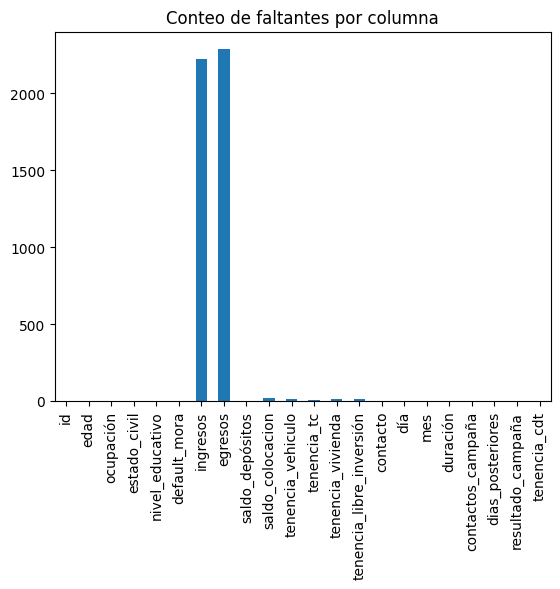

In [6]:
df.isna().sum().plot(kind='bar')
plt.title('Conteo de faltantes por columna')
plt.show()

Se observan algunas columnas con valores faltantes los cuales imputaremos en la siguiente sección.

Procedemos a revisar las variables una por una 

### Tenencia CDT 

In [7]:
df.tenencia_cdt = df.tenencia_cdt.str.title()

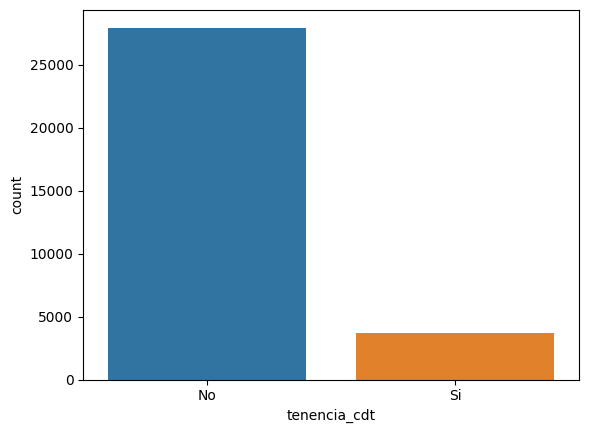

In [8]:
sns.countplot(data=df,x='tenencia_cdt',hue='tenencia_cdt')
plt.show()

Se observa un fuerte desbalance entre las clases, lo cual debemos tener en cuenta al momento de entrenar los modelos.

### Edad

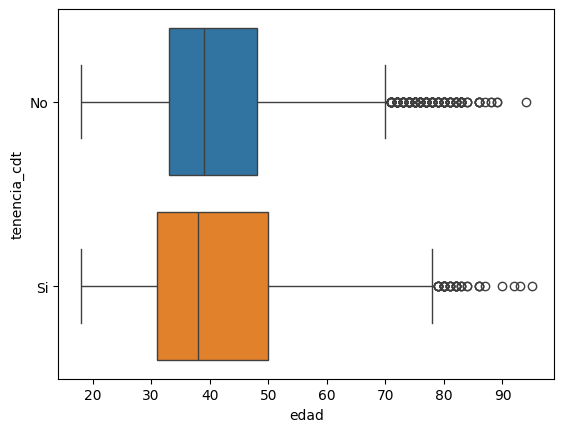

In [9]:
sns.boxplot(data=df,x='edad',y ='tenencia_cdt',hue='tenencia_cdt')
plt.show()

In [10]:
df.groupby('tenencia_cdt')['edad'].agg(['mean','median'])

,mean,median
tenencia_cdt,,
No,40.862165,39.0
Si,41.672140,38.0


Esta variable no parece aportar información relevante por sí sola.

### Ocupación

In [11]:
df.ocupación = df.ocupación.str.strip() # Eliminamos espacios en blanco en algunos valores
df.ocupación = df.ocupación.astype('category') # Convertimos a categoría

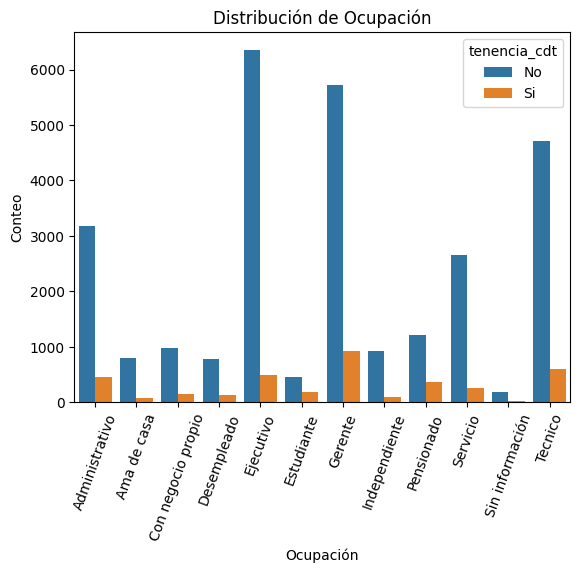

In [12]:
sns.countplot(data=df,x='ocupación',hue='tenencia_cdt')
plt.title('Distribución de Ocupación')
plt.xlabel('Ocupación')
plt.ylabel('Conteo')
plt.xticks(rotation=70)
#plt.savefig('ocupacion.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
round(pd.crosstab(index=df.ocupación, columns=df.tenencia_cdt,normalize='index'),2)

tenencia_cdt,No,Si
ocupación,,
Administrativo,0.88,0.12
Ama de casa,0.91,0.09
Con negocio propio,0.88,0.12
Desempleado,0.86,0.14
Ejecutivo,0.93,0.07
Estudiante,0.71,0.29
Gerente,0.86,0.14
Independiente,0.92,0.08
Pensionado,0.77,0.23


Se evidencia que casi 1 de cada 3 estudiantes adquiere un CDT, y del mismo modo 1 de cada 4 pensionados. 

Por otro lado, vemos cómo la ocupación con menor probabilidad de aquirir un CDT son los ejecutivos. Lo cual se puede deber a que este perfil destina su dinero en inversiones de mayor riesgo y rendimiento, y el CDT le parece menos atractivo.

De aquí podemos empezar planteando 2 cosas:

1. Ofrecer CDT's a a estudiantes y pensionados (ya que estos presentan una probabilidad más alta de adquirirlo).
2. Evitar ejecutivos, amas de casa, independientes y personal de servicio.

### Estado civil

In [14]:
df.estado_civil = df.estado_civil.astype('category') # convertimos a categoría

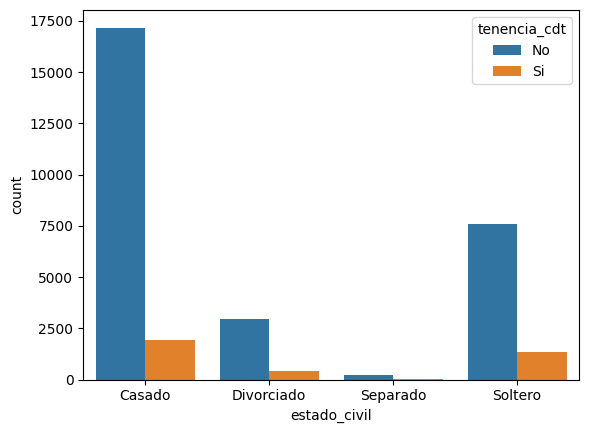

In [15]:
sns.countplot(data=df, x='estado_civil',hue='tenencia_cdt')
plt.show()

In [16]:
pd.crosstab(index=df.estado_civil, columns=df.tenencia_cdt, normalize='index')

tenencia_cdt,No,Si
estado_civil,,
Casado,0.899502,0.100498
Divorciado,0.875626,0.124374
Separado,0.902954,0.097046
Soltero,0.848577,0.151423


Según el estado civil del cliente, es más probable que este adquiera un CDT si es soltero, y menos probable si es casado o separado

### Nivel educativo

In [17]:
categorias_educacion = ['Sin información','Ed. Básica','Pregrado','Posgrado']
df.nivel_educativo = df.nivel_educativo.astype('category').cat.reorder_categories(categorias_educacion) # convertimos a categoría

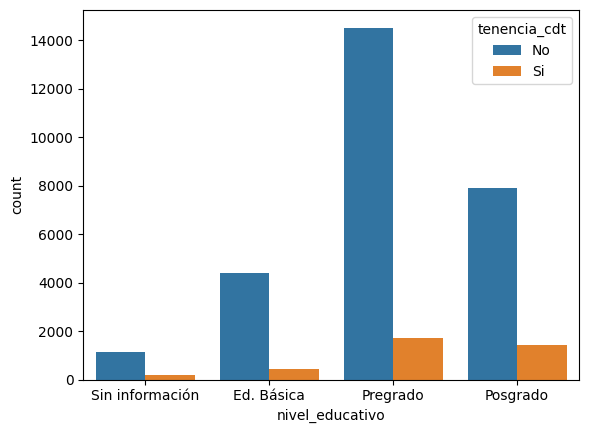

In [18]:
sns.countplot(data=df, x='nivel_educativo',hue='tenencia_cdt')
plt.show()

In [19]:
round(pd.crosstab(index=df.nivel_educativo, columns=df.tenencia_cdt, normalize='index'),2)

tenencia_cdt,No,Si
nivel_educativo,,
Sin información,0.87,0.13
Ed. Básica,0.91,0.09
Pregrado,0.90,0.10
Posgrado,0.85,0.15


Según el nivel de educación, es más probable que el cliente adquiera un CDT si tiene un posgrado, y menos probable si solo cuenta con eduación básica.

### Default - Mora

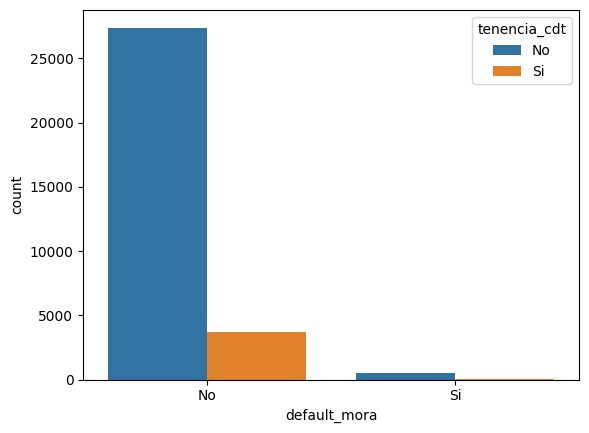

In [20]:
sns.countplot(data=df, x='default_mora', hue='tenencia_cdt')
plt.show()

In [21]:
pd.crosstab(index=df.default_mora, columns=df.tenencia_cdt, normalize='index')

tenencia_cdt,No,Si
default_mora,,
No,0.881720,0.118280
Si,0.929915,0.070085


Es un poco mas probable que los clientes que no han entrado en mora adquieran un CDT, sin embargo no es una diferencia significativa.

### Ingresos

In [22]:
df.ingresos.describe()

count    29420.000000
mean      4304.550279
std       2782.313624
min      -3090.885131
25%       1939.265576
50%       3787.286058
75%       6536.000000
max      13546.541070
Name: ingresos, dtype: float64

In [23]:
df.ingresos[df.ingresos<0].shape

(231,)

Se observa la presencia de valores de ingresos negativos, lo cual pudo ser un error de digitación, sin embargo, se reemplazaran dichos valores con NaN para ser tratados en la siguiente sección.

In [24]:
df.loc[df.ingresos<0,'ingresos'] = np.nan

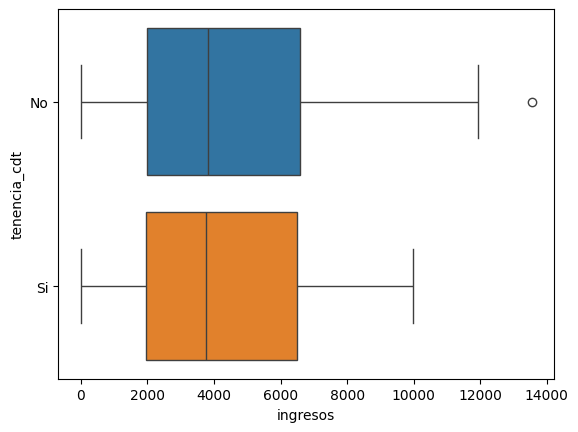

In [25]:
sns.boxplot(data=df, x='ingresos',y='tenencia_cdt',hue='tenencia_cdt')
plt.show()

In [26]:
df.groupby('tenencia_cdt')['ingresos'].agg(['mean','median'])

,mean,median
tenencia_cdt,,
No,4347.269899,3834.00000
Si,4310.667660,3758.81891


Según el gráfico y los valores de la tabla se observa que tanto los clientes que poseen un CDT como los que no, tienen ingresos similares.
Por lo tanto esta variable no parece ser relevante por sí sola.

### Egresos

In [27]:
df.egresos.describe()

count    29359.000000
mean      3797.139234
std       2967.097158
min      -2506.104373
25%       1415.165853
50%       3276.000000
75%       6074.000000
max      10000.000000
Name: egresos, dtype: float64

In [28]:
df.egresos[df.egresos<0].shape

(2438,)

Se observan valores negativos en los Egresos, lo cual se asume que es por error de digitación. Sin embargo, como son muchos los datos incorrectos, en lugar de reemplazar estos por NaN, se toma la decisión de ajustar el signo (asumiendo que ese es el error).

In [29]:
df.egresos = df.egresos.abs()

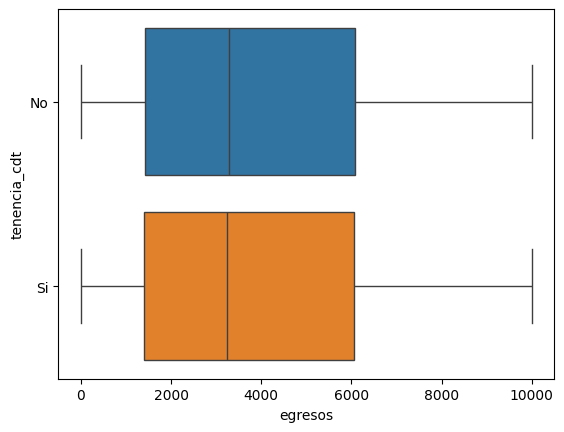

In [30]:
sns.boxplot(data=df, x='egresos',y='tenencia_cdt',hue='tenencia_cdt')
plt.show()

In [31]:
df.groupby('tenencia_cdt')['egresos'].agg(['mean','median'])

,mean,median
tenencia_cdt,,
No,3885.904434,3281.000000
Si,3844.564640,3239.432598


Del mismo modo que con los ingresos, esta variable no parece ser discriminativa.

### Saldo depósitos

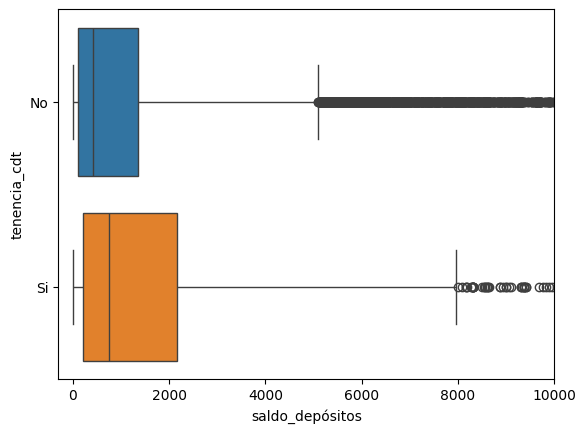

In [32]:
sns.boxplot(data=df, x='saldo_depósitos', y='tenencia_cdt', hue='tenencia_cdt', whis=3)
plt.xlim(-300,10000)
plt.show()

In [33]:
df.groupby('tenencia_cdt')['saldo_depósitos'].agg(['mean','median'])

,mean,median
tenencia_cdt,,
No,1345.532722,418.0
Si,1801.951009,746.0


Se observa que el saldo de depósitos de las personas que adquieren un CDT es mas alto en comparación al otro grupo. Con un promedio de 1801 y una mediana de 746 dentro de los que adquieren el CDT.

### Saldo colocación

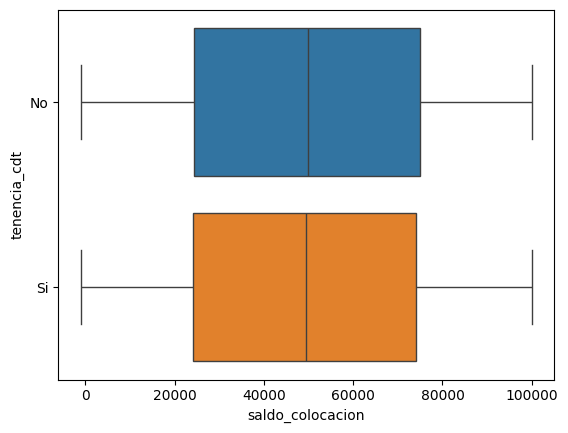

In [34]:
sns.boxplot(data=df, x='saldo_colocacion',y='tenencia_cdt',hue='tenencia_cdt')
plt.show()

In [35]:
df.groupby('tenencia_cdt')['saldo_colocacion'].agg(['mean','median'])

,mean,median
tenencia_cdt,,
No,49637.247340,49910.0
Si,49332.598869,49513.5


Según el gráfico y los valores de la tabla podemos ver que la variable por si sola no es discriminativa.

### Tenencia Vehiculo

In [36]:
df.tenencia_vehiculo = df.tenencia_vehiculo.str.title()

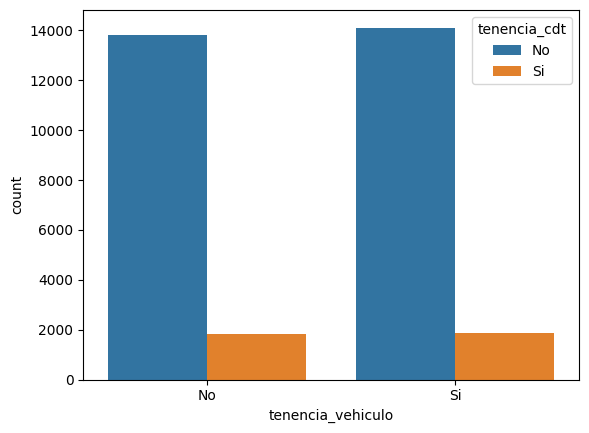

In [37]:
sns.countplot(data=df, x='tenencia_vehiculo', hue='tenencia_cdt')
plt.show()

Esta variable por si sola no parece ser relevante.

### Tenencia Tarjeta de Crédito

In [38]:
df.tenencia_tc = df.tenencia_tc.str.title()

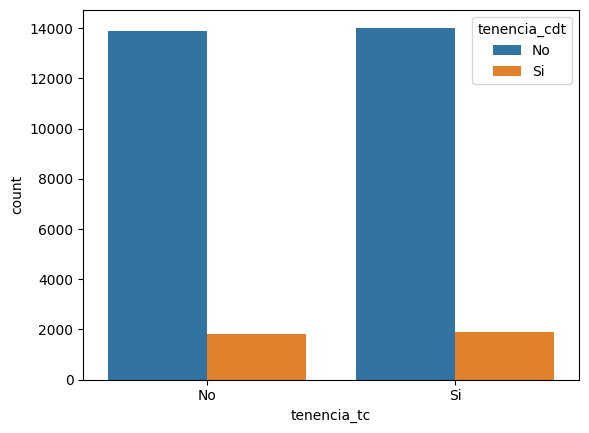

In [39]:
sns.countplot(data=df, x='tenencia_tc', hue='tenencia_cdt')
plt.show()

Esta variable por si sola no parece ser relevante.

### Tenencia Vivienda

In [40]:
df.tenencia_vivienda = df.tenencia_vivienda.str.title()

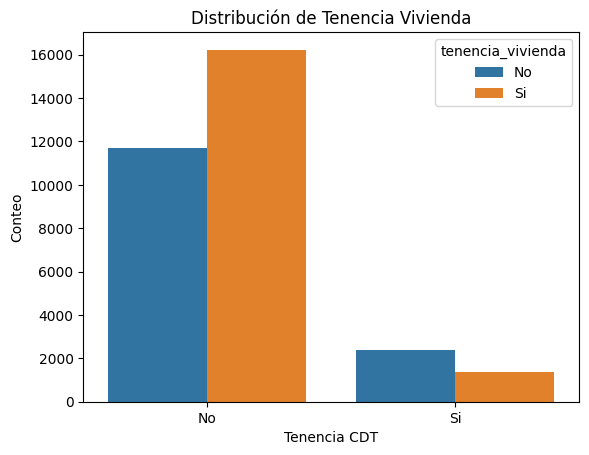

In [41]:
sns.countplot(data=df, x='tenencia_cdt', hue='tenencia_vivienda')
plt.title('Distribución de Tenencia Vivienda')
plt.xlabel('Tenencia CDT')
plt.ylabel('Conteo')
#plt.savefig('tenencia_vivienda.png', dpi=300, bbox_inches='tight')
plt.show()

In [42]:
round(pd.crosstab(columns=df.tenencia_cdt, index=df.tenencia_vivienda, normalize='index'),2)

tenencia_cdt,No,Si
tenencia_vivienda,,
No,0.83,0.17
Si,0.92,0.08


Se evidencia que dentro del grupo de los que adquieren un CDT en su mayoría NO tienen una deuda de vivienda. Lo cual parece indicar que les deja mayor libertad para invertir.

### Tenencia Libre Inversión

In [43]:
df.tenencia_libre_inversión = df.tenencia_libre_inversión.str.title()

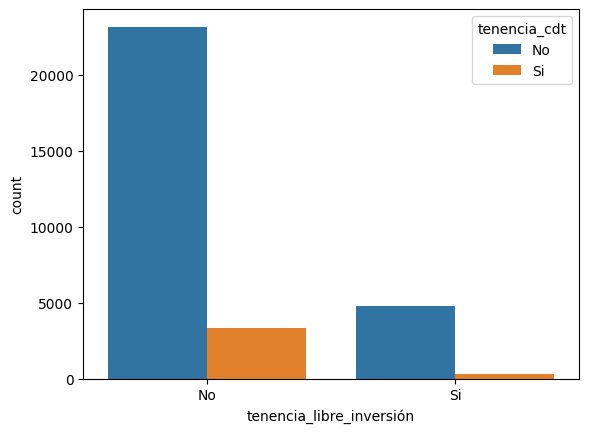

In [44]:
sns.countplot(data=df, x='tenencia_libre_inversión', hue='tenencia_cdt')
plt.show()

In [45]:
round(pd.crosstab(index=df.tenencia_libre_inversión, columns=df.tenencia_cdt, normalize='index'),2)

tenencia_cdt,No,Si
tenencia_libre_inversión,,
No,0.87,0.13
Si,0.94,0.06


Se evidencia que aquellos que aquellos que no poseen un crédito de libre inversión, tienen el doble de probabilidades (12%) de adquirir un CDT en comparación con el otro grupo que sí posee el crédito (6%).

### Contacto

In [46]:
df.contacto = df.contacto.str.title()

categorias_contacto = ['Telefono Fijo', 'Celular', 'Sin Información']
df.contacto = df.contacto.astype('category').cat.reorder_categories(categorias_contacto)

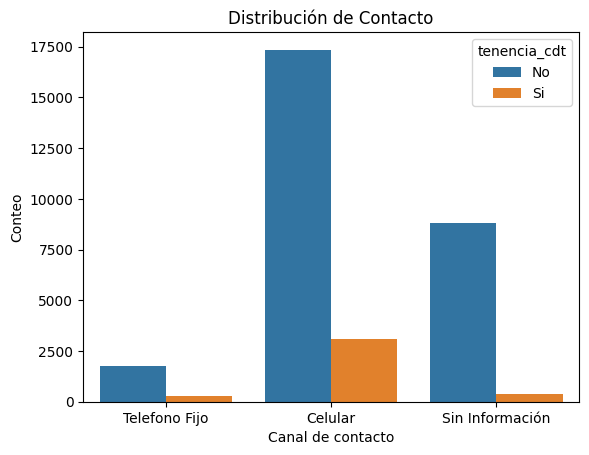

In [47]:
sns.countplot(data=df, x='contacto', hue='tenencia_cdt')
plt.title('Distribución de Contacto')
plt.xlabel('Canal de contacto')
plt.ylabel('Conteo')
#plt.savefig('contacto.png', dpi=300, bbox_inches='tight')
plt.show()

In [48]:
round(pd.crosstab(index=df.contacto, columns=df.tenencia_cdt, normalize='index'),2)

tenencia_cdt,No,Si
contacto,,
Telefono Fijo,0.87,0.13
Celular,0.85,0.15
Sin Información,0.96,0.04


Se evidencia que la forma más efectiva de contactar al cliente es mediante celular, ya que este maximiza la probabilidad de adquirir un CDT en comparación al telefono fijo. Por otro lado, es muy improbable que un registro sin información de contacto adquiera un CDT.

### Día

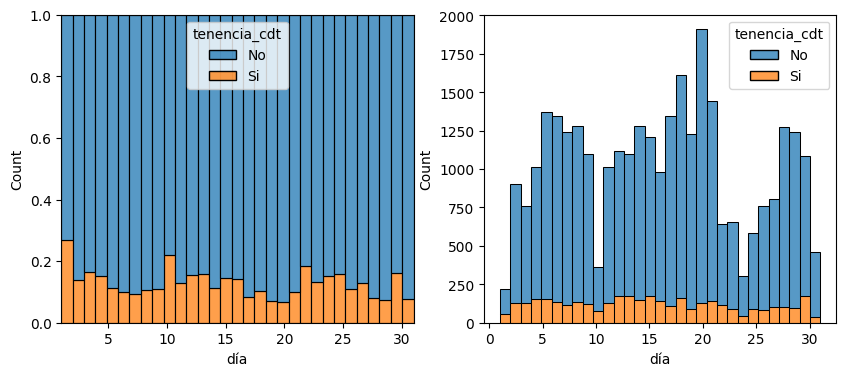

In [49]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(data=df, x='día',bins=31,hue='tenencia_cdt',multiple='fill')
plt.subplot(1,2,2)
sns.histplot(data=df, x='día',bins=31,hue='tenencia_cdt',multiple='stack')
plt.show()

Se evidencia según el primer gráfico que: las personas contactadas en el día 1 y el día 10 tienen una mayor probabilidad de adquirir un CDT en comparación con los otros días. Sin embargo, se debe notar (segundo gráfico) que estos días son aquellos en los que se realizan menos contactos.

### Mes

In [50]:
replace_map_meses = {'jan': 'ene', 'apr': 'abr', 'aug': 'ago', 'dec': 'dic'}
df.mes = df.mes.replace(replace_map_meses)

categorias_mes = ['ene','feb','mar','abr','may','jun','jul','ago','sep','oct','nov','dic']
df.mes = df.mes.astype('category').cat.reorder_categories(categorias_mes)

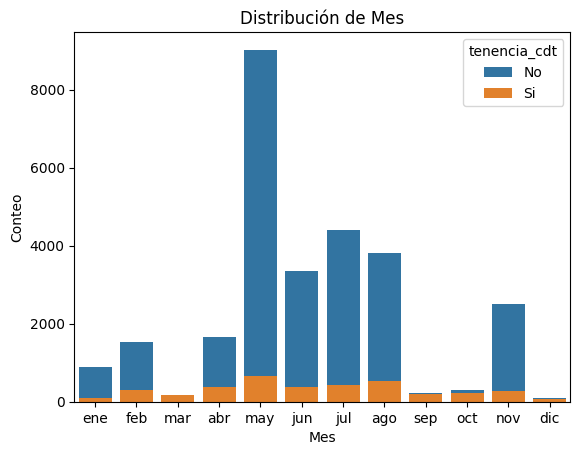

In [51]:
sns.countplot(data=df, x='mes', hue='tenencia_cdt',dodge=False)
plt.title('Distribución de Mes')
plt.xlabel('Mes')
plt.ylabel('Conteo')
#plt.savefig('mes.png', dpi=300, bbox_inches='tight')
plt.show()

In [52]:
round(pd.crosstab(index=df.mes, columns=df.tenencia_cdt, normalize='index').sort_values(by='Si',ascending=False),2)

tenencia_cdt,No,Si
mes,,
mar,0.49,0.51
sep,0.53,0.47
dic,0.54,0.46
oct,0.56,0.44
abr,0.81,0.19
feb,0.83,0.17
ago,0.88,0.12
jun,0.90,0.10
ene,0.90,0.10


Se evidencia que al contactar con los clientes en los meses de marzo, septiembre, octubre y diciembre se tiene una mayor probabilidad de que este adquiera un CDT en comparación con los demás meses.

### Duración

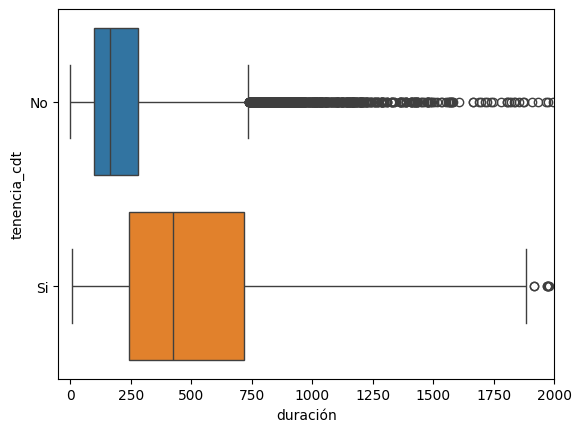

In [53]:
sns.boxplot(data=df, x='duración', y='tenencia_cdt', hue='tenencia_cdt', whis=2.5)
plt.xlim(-50,2000)
plt.show()

Se observa cómo aquellos clientes que adquirieron un CDT tuvieron un tiempo de contacto de mayor duración.

Sin embargo, se debe tener cuidado con esta variable, puesto que si se desea predecir si un cliente va a adquirir un CDT, no sabremos cuánto durará la llamada antes de contactar con el cliente (fuga de información). Por lo tanto esta es una variable explicativa mas no predictiva.

### Contactos campaña

In [54]:
df.contactos_campaña.unique().max()

63

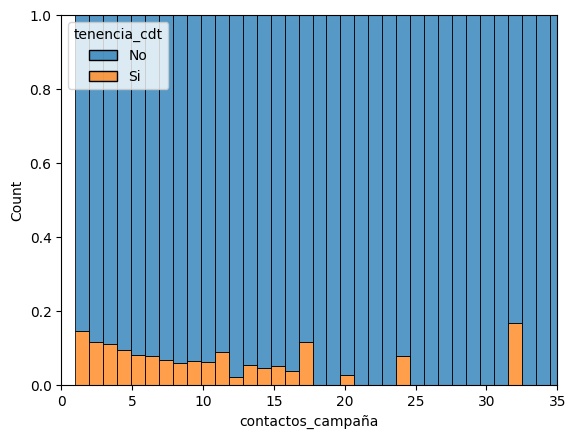

In [55]:
sns.histplot(data=df, x='contactos_campaña', hue='tenencia_cdt',bins=63,multiple='fill')
plt.xlim(0,35)
plt.show()

Se observa que la probabilidad de que un cliente adquiera un CDT decrece entre más se le contacte. Es decir, ser insistente no parece tener el efecto esperado de convencer al cliente.

### Días posteriores

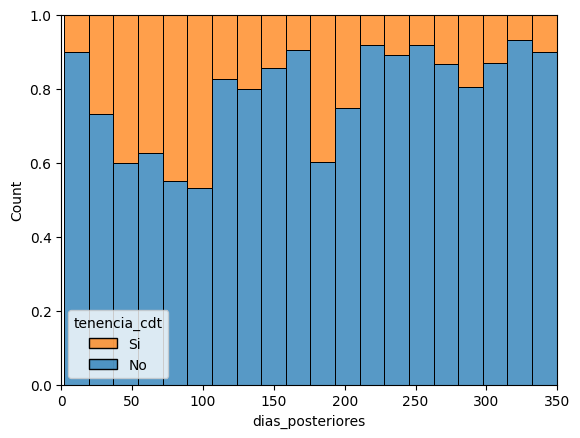

In [56]:
colores = {'No': sns.color_palette()[0], 'Si': sns.color_palette()[1]}
sns.histplot(data=df[df.dias_posteriores>1], x='dias_posteriores', hue='tenencia_cdt',bins=50,multiple='fill',palette=colores)
plt.xlim(0,350)
plt.show()

Se evidencia que es más probable que un cliente adquiera un CDT si se le contacta entre los 50 y los 100 días posteriores al último contacto.

### Resultado campaña

In [57]:
df.resultado_campaña = df.resultado_campaña.astype('category')

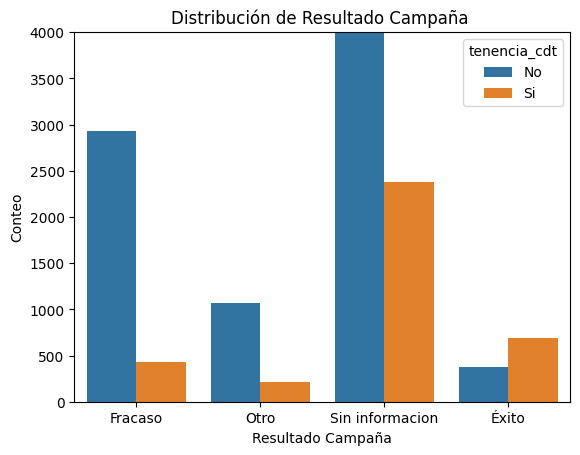

In [58]:
sns.countplot(data=df, x='resultado_campaña', hue='tenencia_cdt')
plt.title('Distribución de Resultado Campaña ')
plt.xlabel('Resultado Campaña')
plt.ylabel('Conteo')
plt.ylim(0,4000)
#plt.savefig('resultado_campana.png', dpi=300, bbox_inches='tight')
plt.show()

In [59]:
round(pd.crosstab(index=df.resultado_campaña, columns=df.tenencia_cdt, normalize='index'),2)

tenencia_cdt,No,Si
resultado_campaña,,
Fracaso,0.87,0.13
Otro,0.83,0.17
Sin informacion,0.91,0.09
Éxito,0.35,0.65


Se evidencia que si el resultado de la campaña anterior fue exitosa, es más probable que el cliente adquiera de nuevo un CDT.
Siendo específicos, de cada 100 clientes con los que se haya tenido éxito en la campaña anterior, 65 de ellos invertirán de nuevo en un CDT.

### Ingresos Vs Egresos

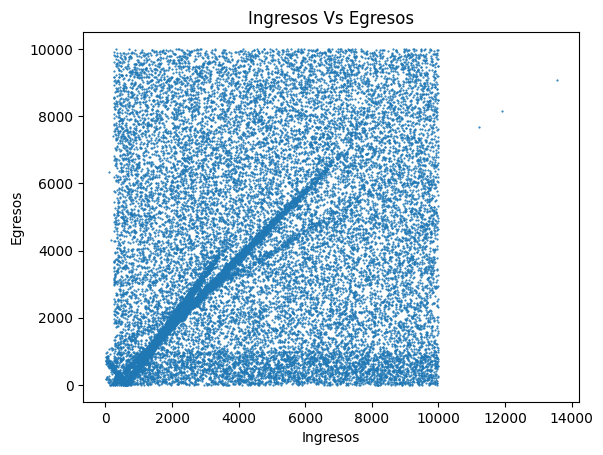

In [60]:
plt.scatter(x=df.ingresos, y=df.egresos,s=0.3)
plt.xlabel('Ingresos')
plt.ylabel('Egresos')
plt.title('Ingresos Vs Egresos')
plt.show()

Se observan 3 outliers, sin embargo parecen seguir una de las tendencias.

## 3. Limpieza de datos

In [61]:
df.isna().sum()

id                             0
edad                           0
ocupación                      0
estado_civil                   0
nivel_educativo                0
default_mora                   0
ingresos                    2458
egresos                     2288
saldo_depósitos                0
saldo_colocacion              18
tenencia_vehiculo             16
tenencia_tc                    6
tenencia_vivienda             12
tenencia_libre_inversión      15
contacto                       0
día                            0
mes                            0
duración                       0
contactos_campaña              0
dias_posteriores               0
resultado_campaña              0
tenencia_cdt                   0
dtype: int64

Comenzamos con imputar los faltantes (NaN) de las comlumnas:

- Ingresos 
- Egresos 
- Saldo colocacion 
- Tenencia vehiculo 
- Tenencia tc 
- Tenencia vivienda 
- Tenencia libre inversión


Eliminamos los faltantes de las columnas que presentan pocos de estos.

In [62]:
cols_to_drop_na = ['saldo_colocacion', 'tenencia_vehiculo', 'tenencia_tc', 'tenencia_vivienda', 'tenencia_libre_inversión']
df = df.dropna(subset=cols_to_drop_na)

Analizamos un poco más a detalle los faltantes en ingresos

In [63]:
df[df.ingresos.isna()]['ocupación'].value_counts()

ocupación
Ejecutivo             535
Gerente               471
Tecnico               403
Administrativo        301
Servicio              213
Pensionado            152
Con negocio propio     88
Desempleado            78
Independiente          74
Ama de casa            71
Estudiante             48
Sin información        16
Name: count, dtype: int64

Se concluye que se podrían rellenar estos faltantes agrupando por la Ocupación y tomando la mediana del respectivo grupo al que pertenezca.

In [64]:
df.groupby('ocupación')['ingresos'].median()

ocupación
Administrativo        3770.298567
Ama de casa           3938.000000
Con negocio propio    3779.774583
Desempleado           3580.650325
Ejecutivo             3858.000000
Estudiante            3706.359159
Gerente               3911.000000
Independiente         3960.811578
Pensionado            3622.297425
Servicio              3948.000000
Sin información       3454.734545
Tecnico               3725.000000
Name: ingresos, dtype: float64

Sin embargo, vemos que la mediana de ingresos no varía mucho según la ocupación. Evidenciando que un estudiante y un desempleado ganan casi lo mismo que un gerente, lo cual no tiene mucho sentido. 

Por lo tanto, basandonos en esto y en el boxplot de los ingresos que vimos en el EDA, se toma la decisión de no tener en cuenta esta variable.

Veamos ahora la variable Egresos.

In [65]:
df[df.egresos.isna()]['ocupación'].value_counts()

ocupación
Gerente               500
Ejecutivo             454
Tecnico               385
Administrativo        282
Servicio              207
Pensionado            106
Con negocio propio     93
Independiente          74
Ama de casa            59
Desempleado            56
Estudiante             42
Sin información        19
Name: count, dtype: int64

In [66]:
df.groupby('ocupación')['egresos'].median()

ocupación
Administrativo        3268.000000
Ama de casa           3161.000000
Con negocio propio    3200.500000
Desempleado           3079.033984
Ejecutivo             3334.374336
Estudiante            3480.700819
Gerente               3296.895461
Independiente         3373.500000
Pensionado            3223.549721
Servicio              3272.032278
Sin información       3188.997296
Tecnico               3228.000000
Name: egresos, dtype: float64

Sucede de manera similar que con los ingresos, por lo tanto tampoco la tendremos en cuenta.

Eliminamos las columnas que no vamos a utilizar

In [67]:
cols_to_drop = ['id', 'duración', 'ingresos', 'egresos']
df = df.drop(columns=cols_to_drop)

In [68]:
df.head()

,edad,ocupación,estado_civil,nivel_educativo,default_mora,saldo_depósitos,saldo_colocacion,tenencia_vehiculo,tenencia_tc,tenencia_vivienda,tenencia_libre_inversión,contacto,día,mes,contactos_campaña,dias_posteriores,resultado_campaña,tenencia_cdt
0,56,Administrativo,Casado,Sin información,No,1933,97679.0,No,No,No,No,Telefono Fijo,19,nov,2,1,Sin informacion,No
1,31,Sin información,Casado,Pregrado,No,3,57402.0,Si,No,No,No,Celular,20,jul,2,1,Sin informacion,No
2,27,Servicio,Casado,Pregrado,No,891,99091.0,No,No,Si,No,Celular,18,jul,1,1,Sin informacion,No
3,57,Gerente,Separado,Posgrado,No,3287,61662.0,Si,Si,No,No,Celular,22,jun,1,84,Éxito,Si
6,56,Pensionado,Casado,Pregrado,No,1044,507.0,No,No,No,No,Telefono Fijo,3,jul,2,1,Sin informacion,Si


## 4. Entrenamiento de modelos

In [69]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from keras.callbacks import EarlyStopping
from keras.models import Sequential
from keras.layers import Dense, Input, Dropout
from keras.optimizers import Adam
import tensorflow as tf

random.seed(0)
np.random.seed(0)
tf.random.set_seed(0)

Separamos la columna objetivo de los datos de entrenamiento

In [70]:
X = df.drop(columns=['tenencia_cdt'])
y = df.tenencia_cdt.map({'No':0, 'Si':1})

Particionamos los datos en entrenamiento, validación y prueba

In [71]:
X_train, X_temporal, y_train, y_temporal = train_test_split(X, y, test_size=0.3, stratify=y, random_state= 42)
X_val, X_test, y_val, y_test             = train_test_split(X_temporal, y_temporal, test_size=0.5, stratify=y_temporal, random_state=42)

Creamos los pipelines de preprocesamiento

In [72]:
num_cols = X.select_dtypes(['number']).columns.to_list()
cat_cols = X.select_dtypes(['str','category']).columns.to_list()

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
    ('num', numerical_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

Definimos el Cross-Validation a utilizar

In [73]:
cv = StratifiedKFold(n_splits=5, shuffle=True,random_state=42)

### **Regresión Logística**

Creamos el pipeline para el modelo logístico

In [74]:
pipeline_LR = Pipeline([
    ('preprocessor',preprocessor),
    ('classifier',LogisticRegression(max_iter=1000, solver='liblinear', class_weight='balanced', random_state=42))
])

In [75]:
param_grid_LR = {'classifier__C': [0.01, 0.1, 1, 10],
              'classifier__penalty': ['l1', 'l2']}

logistic_model = GridSearchCV(estimator=pipeline_LR, 
                              param_grid= param_grid_LR, 
                              cv= cv,
                              scoring='roc_auc',
                              n_jobs=-1)

Entrenamos el modelo

In [76]:
import warnings
warnings.filterwarnings("ignore")

In [77]:
logistic_model.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...liblinear'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.01, 0.1, ...], 'classifier__penalty': ['l1', 'l2']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is dis

In [78]:
print('Mejores Parámetros Regresión Logística: ',logistic_model.best_params_)

Mejores Parámetros Regresión Logística:  {'classifier__C': 0.1, 'classifier__penalty': 'l1'}


In [79]:
resultados_cv_LR = pd.DataFrame(logistic_model.cv_results_)
mejor_fila = resultados_cv_LR.loc[logistic_model.best_index_]

print(f"ROBUSTEZ DEL MODELO LOGÍSTICO (Basado en {logistic_model.n_splits_} Folds)\n")
print(f"Media: {mejor_fila['mean_test_score']:.3f}")
print(f"Desviación Estándar: {mejor_fila['std_test_score']:.3f}")

ROBUSTEZ DEL MODELO LOGÍSTICO (Basado en 5 Folds)

Media: 0.760
Desviación Estándar: 0.014


In [80]:
# Tabla de valores del Cross-Val Logístico
resultados_cv_LR.iloc[:,4:].sort_values(by='mean_test_score', ascending=False)

,param_classifier__C,param_classifier__penalty,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
2,0.10,l1,"{'classifier__C': 0.1, 'classifier__penalty': ...",0.764730,0.736676,0.778102,0.755157,0.766168,0.760167,0.013823,1
3,0.10,l2,"{'classifier__C': 0.1, 'classifier__penalty': ...",0.764726,0.736573,0.777250,0.754573,0.766301,0.759885,0.013695,2
4,1.00,l1,"{'classifier__C': 1, 'classifier__penalty': 'l1'}",0.764614,0.736515,0.776573,0.754500,0.766190,0.759678,0.013532,3
5,1.00,l2,"{'classifier__C': 1, 'classifier__penalty': 'l2'}",0.764596,0.736486,0.776468,0.754363,0.766131,0.759609,0.013519,4
6,10.00,l1,"{'classifier__C': 10, 'classifier__penalty': '...",0.764562,0.736491,0.776386,0.754341,0.766110,0.759578,0.013494,5
7,10.00,l2,"{'classifier__C': 10, 'classifier__penalty': '...",0.764548,0.736478,0.776374,0.754315,0.766108,0.759565,0.013496,6
1,0.01,l2,"{'classifier__C': 0.01, 'classifier__penalty':...",0.763467,0.735046,0.777734,0.753190,0.764157,0.758719,0.014175,7
0,0.01,l1,"{'classifier__C': 0.01, 'classifier__penalty':...",0.748356,0.726917,0.770546,0.741164,0.750550,0.747507,0.014177,8


Se observa que el resultado entre los folds es consistente y no presenta diferencias significativas.

#### Evaluación en el conjunto de validación 

In [81]:
y_val_pred_LR = logistic_model.predict(X_val)

report_LR = classification_report(y_val,y_val_pred_LR)
print(report_LR)

              precision    recall  f1-score   support

           0       0.94      0.77      0.85      4182
           1       0.27      0.65      0.38       556

    accuracy                           0.75      4738
   macro avg       0.61      0.71      0.61      4738
weighted avg       0.86      0.75      0.79      4738



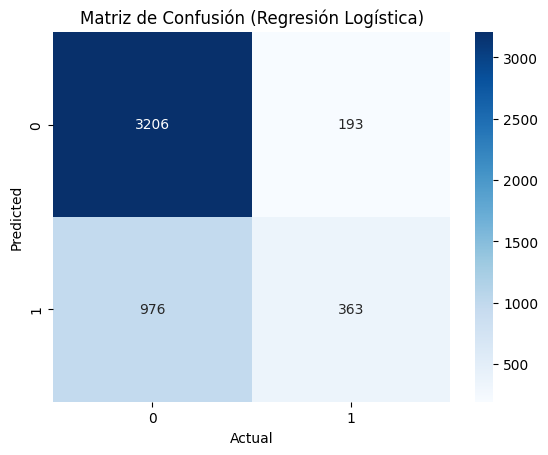

In [82]:
conf_matrix_LR = confusion_matrix(y_val, y_val_pred_LR).T

sns.heatmap(conf_matrix_LR, annot=True, cmap='Blues', fmt='d')
plt.title('Matriz de Confusión (Regresión Logística)')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

Graficamos la curva ROC

ROC AUC: 0.780


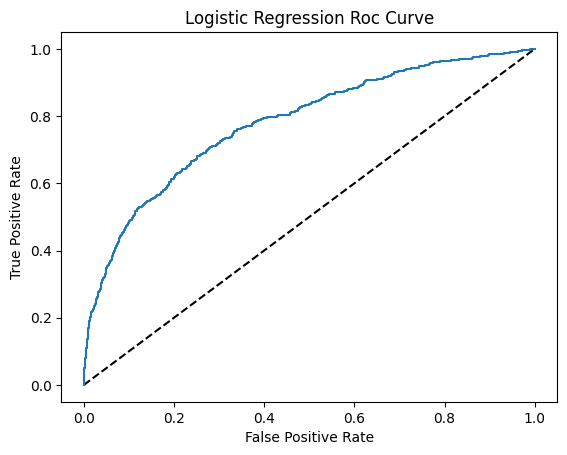

In [83]:
from sklearn.metrics import roc_curve, auc

y_val_pred_probs = logistic_model.predict_proba(X_val)[:,1]

fpr, tpr, umbrales = roc_curve(y_val, y_val_pred_probs)

plt.plot([0,1],[0,1],'k--')
plt.plot(fpr,tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression Roc Curve')
print(f'ROC AUC: {auc(fpr, tpr):.3f}')
plt.show()

#### Feature importance (Regresión Logística)

In [84]:
best_model_LR = logistic_model.best_estimator_

model_LR = best_model_LR.named_steps['classifier']
nombres_variables = best_model_LR.named_steps['preprocessor'].get_feature_names_out()

In [85]:
# Organizamos los coeficientes en un DataFrame
coeficientes = pd.DataFrame({'Variable': nombres_variables,
                             'Coeficiente': model_LR.coef_[0]})
coeficientes = coeficientes.sort_values(by='Coeficiente', ascending=True)

In [86]:
# Filtramos para quedarnos con las más relevantes
coeficientes = coeficientes[(coeficientes['Coeficiente']<-0.25)|(coeficientes['Coeficiente']>0.4)]

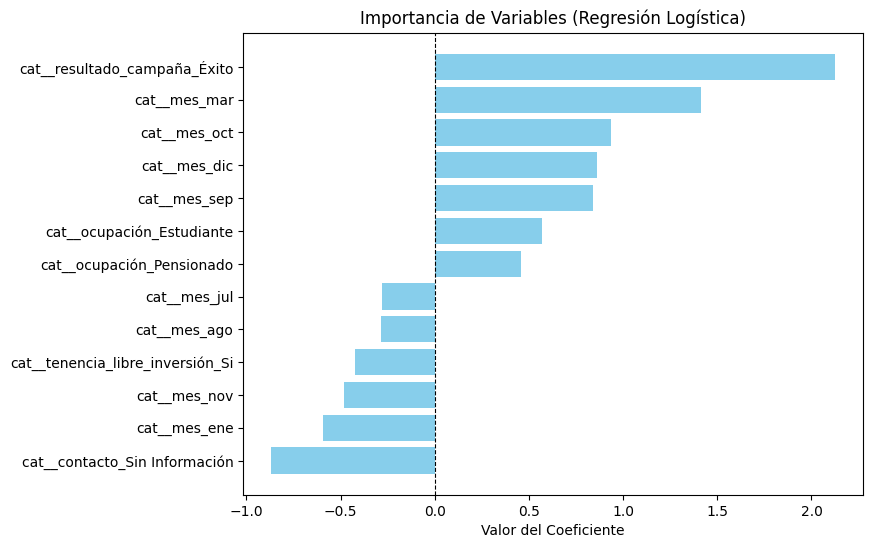

In [87]:
# Graficamos 
plt.figure(figsize=(8, 6))
plt.barh(coeficientes['Variable'], coeficientes['Coeficiente'], color='skyblue')
plt.title("Importancia de Variables (Regresión Logística)")
plt.xlabel("Valor del Coeficiente")
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
#plt.savefig('feat_import_REG_LOG.png', dpi=300, bbox_inches='tight')
plt.show()

Según este modelo las variables más relevantes en el entrenamiento fueron las siguientes:

Variables que incrementan la probabilidad de éxito:
* Resultado_campaña_exito.
* Meses: Marzo, septiembre, octubre y dicembre.
* Ocupación: Estudiante y pensionado. 

Variables que disminuyen la probabilidad de éxito:
* Contacto_sin_información.
* Meses: Enero, julio, agosto y noviembre.
* Tenencia_libre_inversión_si. 


Todo lo anterior confirma lo que vimos en el análisis exploratorio de datos.

### **XGBoost**

In [88]:
# ratio para manejar el desbalance de las clases
ratio_desbalance = y_train.value_counts()[0] / y_train.value_counts()[1]

Creamos el pipeline del xgboost

In [89]:
pipeline_XGB = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(eval_metric='logloss', random_state=42, scale_pos_weight=ratio_desbalance))
])

In [90]:
param_grid_XGB = {'classifier__n_estimators': [100, 200, 300],
                  'classifier__learning_rate': [0.01, 0.05, 0.1],
                  'classifier__max_depth': [3, 5, 7]}

xgboost = GridSearchCV(estimator=pipeline_XGB, 
                              param_grid= param_grid_XGB, 
                              cv= cv,
                              scoring='roc_auc',
                              n_jobs=-1)

Entrenamos el modelo

In [91]:
xgboost.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__learning_rate': [0.01, 0.05, ...], 'classifier__max_depth': [3, 5, ...], 'classifier__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the 

In [92]:
print('Mejores Parámetros XGBoost: ',xgboost.best_params_)

Mejores Parámetros XGBoost:  {'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 300}


In [93]:
resultados_cv_XGB = pd.DataFrame(xgboost.cv_results_)
mejor_fila_XGB = resultados_cv_XGB.loc[xgboost.best_index_]

print(f"ROBUSTEZ DEL XGBoost (Basado en {xgboost.n_splits_} Folds)\n")
print(f"Media: {mejor_fila_XGB['mean_test_score']:.3f}")
print(f"Desviación Estándar: {mejor_fila_XGB['std_test_score']:.3f}")

ROBUSTEZ DEL XGBoost (Basado en 5 Folds)

Media: 0.788
Desviación Estándar: 0.008


In [94]:
# Tabla de valores del Cross-Val XGBoost
resultados_cv_XGB.iloc[xgboost.best_index_:-8, 4:]

,param_classifier__learning_rate,param_classifier__max_depth,param_classifier__n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
11,0.05,3,300,"{'classifier__learning_rate': 0.05, 'classifie...",0.782150,0.775423,0.792566,0.795582,0.792375,0.787619,0.007605,1
12,0.05,5,100,"{'classifier__learning_rate': 0.05, 'classifie...",0.773223,0.765442,0.787607,0.785117,0.787489,0.779776,0.008919,8
13,0.05,5,200,"{'classifier__learning_rate': 0.05, 'classifie...",0.769186,0.773151,0.785791,0.790285,0.787308,0.781144,0.008367,7
14,0.05,5,300,"{'classifier__learning_rate': 0.05, 'classifie...",0.766342,0.772739,0.782842,0.786658,0.784378,0.778592,0.007758,9
15,0.05,7,100,"{'classifier__learning_rate': 0.05, 'classifie...",0.769748,0.767269,0.780792,0.783107,0.784353,0.777054,0.007114,10
16,0.05,7,200,"{'classifier__learning_rate': 0.05, 'classifie...",0.756152,0.765095,0.773013,0.779870,0.772708,0.769368,0.008095,18
17,0.05,7,300,"{'classifier__learning_rate': 0.05, 'classifie...",0.744847,0.759947,0.764155,0.772772,0.765286,0.761401,0.009253,22
18,0.10,3,100,"{'classifier__learning_rate': 0.1, 'classifier...",0.781486,0.767889,0.791818,0.789081,0.789092,0.783873,0.008703,5


Se observa que los resultados entre los splits son consistentes y no hay diferencias significativas.

#### Evaluación en el conjunto de validación 

In [95]:
y_val_pred_XGB = xgboost.predict(X_val)

report_XGB = classification_report(y_val,y_val_pred_XGB)
print(report_XGB)

              precision    recall  f1-score   support

           0       0.94      0.83      0.88      4182
           1       0.33      0.62      0.43       556

    accuracy                           0.81      4738
   macro avg       0.64      0.73      0.66      4738
weighted avg       0.87      0.81      0.83      4738



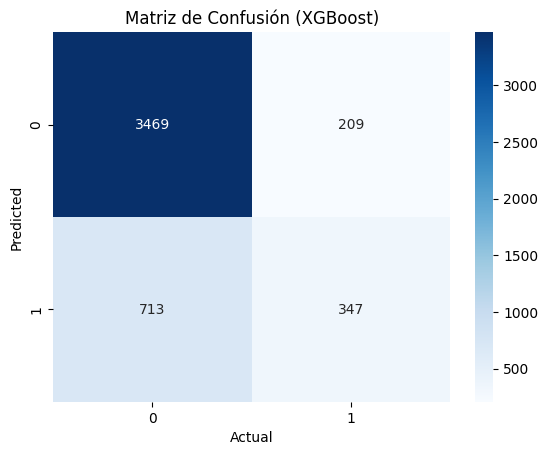

In [96]:
conf_matrix_XGB = confusion_matrix(y_val, y_val_pred_XGB).T

sns.heatmap(conf_matrix_XGB, annot=True, cmap='Blues', fmt='d')
plt.title('Matriz de Confusión (XGBoost)')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

Graficamos la curva ROC

ROC AUC: 0.795


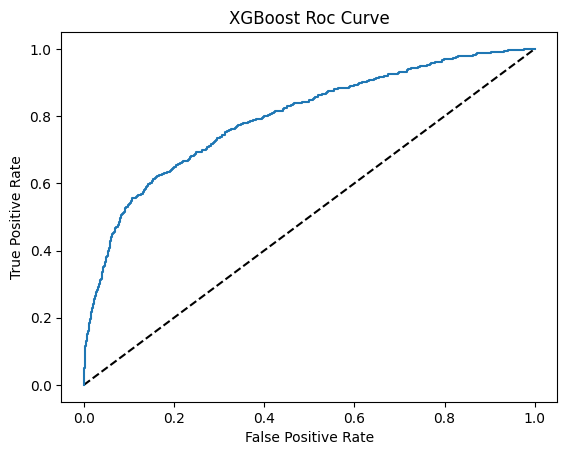

In [97]:
y_val_pred_probs = xgboost.predict_proba(X_val)[:,1]

fpr, tpr, umbrales = roc_curve(y_val, y_val_pred_probs)

plt.plot([0,1],[0,1],'k--')
plt.plot(fpr,tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost Roc Curve')
print(f'ROC AUC: {auc(fpr, tpr):.3f}')
plt.show()

Evaluamos ajustando el umbral. Buscamos igualar la sensibilidad de la regresión logística para tener una mejor comparativa.

In [98]:
umbral_XGB = 0.471
y_val_pred_XGB = (xgboost.predict_proba(X_val)[:,1]>=umbral_XGB)*1

report_XGB = classification_report(y_val,y_val_pred_XGB)
print(report_XGB)

              precision    recall  f1-score   support

           0       0.95      0.79      0.86      4182
           1       0.30      0.65      0.41       556

    accuracy                           0.78      4738
   macro avg       0.62      0.72      0.64      4738
weighted avg       0.87      0.78      0.81      4738



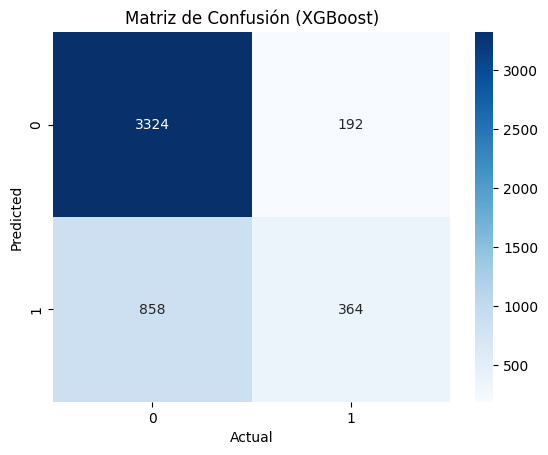

In [99]:
conf_matrix_XGB = confusion_matrix(y_val, y_val_pred_XGB).T

sns.heatmap(conf_matrix_XGB, annot=True, cmap='Blues', fmt='d')
plt.title('Matriz de Confusión (XGBoost)')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

#### Feature importance (XGBoost)

In [100]:
import shap

 97%|=================== | 4578/4738 [00:17<00:00]       

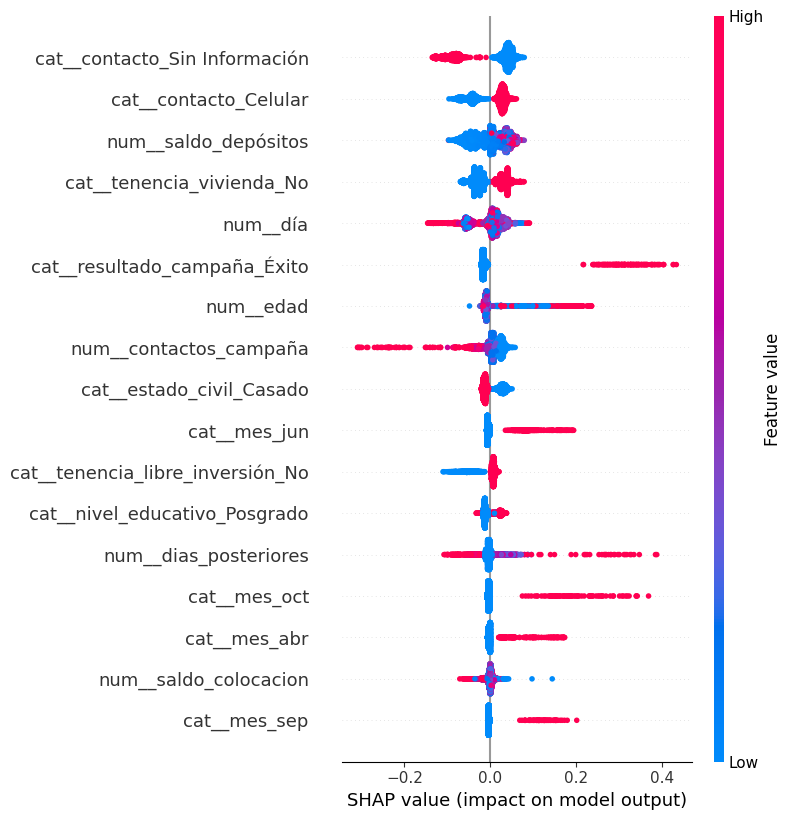

In [101]:
best_model_XGB = xgboost.best_estimator_
model_XGB  = best_model_XGB.named_steps['classifier']

X_bg = best_model_XGB[:-1].transform(X_train)

explainer = shap.TreeExplainer(model_XGB, data=X_bg, feature_perturbation="interventional", model_output="probability")

X_exp = best_model_XGB[:-1].transform(X_test)
shap_values = explainer.shap_values(X_exp)

# Gráfico
feat_names = best_model_XGB[:-1].get_feature_names_out()
shap.summary_plot(shap_values, X_exp, feature_names=feat_names, max_display=17)
i = 0
shap.force_plot(explainer.expected_value, shap_values[i],
                X_exp[i,:] if hasattr(X_exp, "toarray") else X_exp[i],
                feature_names=feat_names)

### **Red Neuronal**

In [102]:
# Preprocesamos los datos para la red
X_train_transf = preprocessor.fit_transform(X_train)
X_val_transf = preprocessor.transform(X_val)
X_test_transf = preprocessor.transform(X_test)

Arquitectura de la red

In [103]:
# Inicializamos
red_neuronal = Sequential()

input_dimension = X_train_transf.shape[1]
output_dimension = 1

# Capas
red_neuronal.add(Input(shape=(input_dimension,)))  # Capa entrada

red_neuronal.add(Dense(40, activation='relu'))     # Capa oculta 1
red_neuronal.add(Dropout(0.3))

red_neuronal.add(Dense(16, activation='relu'))     # Capa oculta 2
red_neuronal.add(Dropout(0.2))

red_neuronal.add(Dense(output_dimension, activation='sigmoid'))   # Capa salida

# Información de la red neuronal
red_neuronal.summary()

# Compilador
eta = 0.0005
optimizador = Adam(learning_rate = eta)
red_neuronal.compile(optimizer=optimizador, loss='binary_crossentropy', metrics=[tf.keras.metrics.AUC(name='auc')])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 40)             │         2,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,913 (11.38 KB)

 Trainable params: 2,913 (11.38 KB)

 Non-trainable params: 0 (0.00 B)

In [104]:
# Calculamos los pesos para el desbalance
pesos_calculados = compute_class_weight(
    class_weight='balanced', 
    classes=np.unique(y_train), 
    y=y_train
)

pesos_clases = dict(zip(np.unique(y_train), pesos_calculados))

print("Pesos asignados:", pesos_clases)

Pesos asignados: {0: 0.5664616961311811, 1: 4.2615651503469545}


Entrenamos la red

In [105]:
early_stp = EarlyStopping(
    monitor='val_loss',   
    patience=10,              # Si pasan 15 epocas y la línea no baja, stop
    restore_best_weights=True # Para retornar el modelo exacto de la epoca donde le fue mejor
)

n_epochs = 500
s_minibatches = 512
historia = red_neuronal.fit(X_train_transf, y_train, epochs=n_epochs, batch_size=s_minibatches, class_weight=pesos_clases,
                      validation_data=(X_val_transf,y_val), verbose=1, callbacks = early_stp)

Epoch 1/500
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - auc: 0.4769 - loss: 0.7231 - val_auc: 0.5216 - val_loss: 0.6919
Epoch 2/500
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.5603 - loss: 0.6895 - val_auc: 0.6510 - val_loss: 0.6760
Epoch 3/500
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.6235 - loss: 0.6689 - val_auc: 0.6986 - val_loss: 0.6567
Epoch 4/500
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.6719 - loss: 0.6477 - val_auc: 0.7180 - val_loss: 0.6377
Epoch 5/500
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.7002 - loss: 0.6334 - val_auc: 0.7299 - val_loss: 0.6140
Epoch 6/500
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.7126 - loss: 0.6227 - val_auc: 0.7392 - val_loss: 0.6020
Epoch 7/500
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.7216 - loss: 0.6165 - val_auc: 0.7460 - val_loss: 0.5998
Epoch 8/500
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.7294 - loss: 0.6083 - val_auc: 0.7511 - val_loss: 0.5931
Epoch 9/500
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - auc: 0.7324

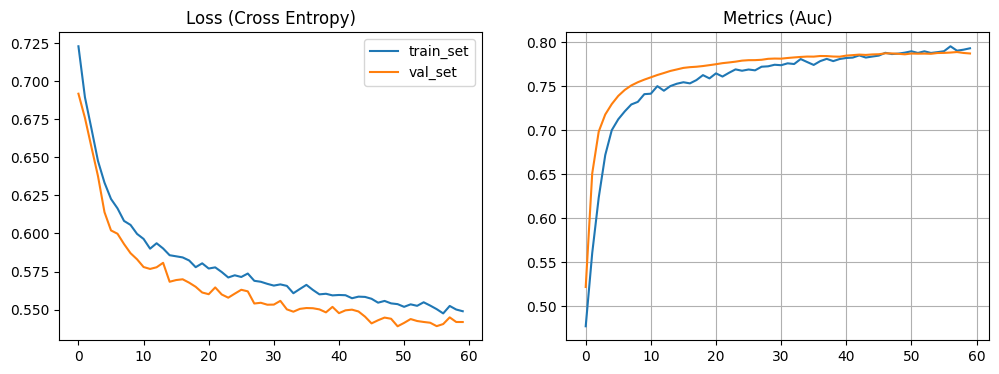

In [106]:
fig, axs = plt.subplots(1,2, figsize=(12,4))
axs[0].set_title('Loss (Cross Entropy)')
axs[0].plot(historia.history['loss'], label='train_set')
axs[0].plot(historia.history['val_loss'], label='val_set')
axs[1].set_title('Metrics (Auc)')
axs[1].plot(historia.history['auc'])
axs[1].plot(historia.history['val_auc'])
axs[0].legend()
axs[1].grid();

In [107]:
print(f'Auc (Train): {red_neuronal.evaluate(X_train_transf, y_train)[1]:.2f}')
print(f'Auc (Val): {red_neuronal.evaluate(X_val_transf, y_val)[1]:.2f}')

691/691 ━━━━━━━━━━━━━━━━━━━━ 1s 714us/step - auc: 0.8055 - loss: 0.5255
Auc (Train): 0.81
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 661us/step - auc: 0.7865 - loss: 0.5390
Auc (Val): 0.79


#### Evaluamos en el conjunto de validación

In [108]:
umbral_red = 0.48
y_val_pred_red = (red_neuronal.predict(X_val_transf)>=umbral_red)*1

report_red = classification_report(y_val,y_val_pred_red)
print(report_red)

149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 556us/step
              precision    recall  f1-score   support

           0       0.94      0.79      0.86      4182
           1       0.29      0.64      0.40       556

    accuracy                           0.78      4738
   macro avg       0.62      0.72      0.63      4738
weighted avg       0.87      0.78      0.81      4738



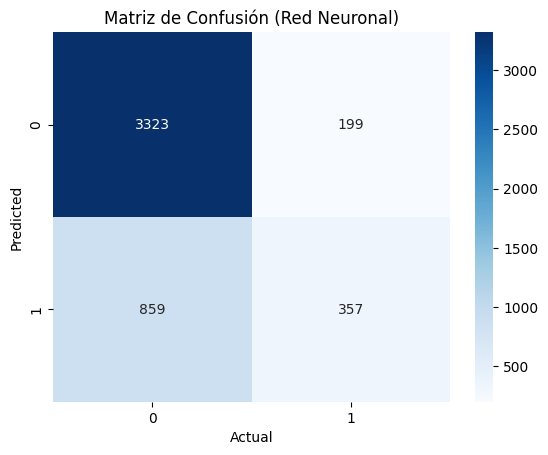

In [109]:
conf_matrix_red = confusion_matrix(y_val, y_val_pred_red).T

sns.heatmap(conf_matrix_red, annot=True, cmap='Blues', fmt='d')
plt.title('Matriz de Confusión (Red Neuronal)')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

Graficamos la cruva ROC

149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 493us/step
ROC AUC: 0.79


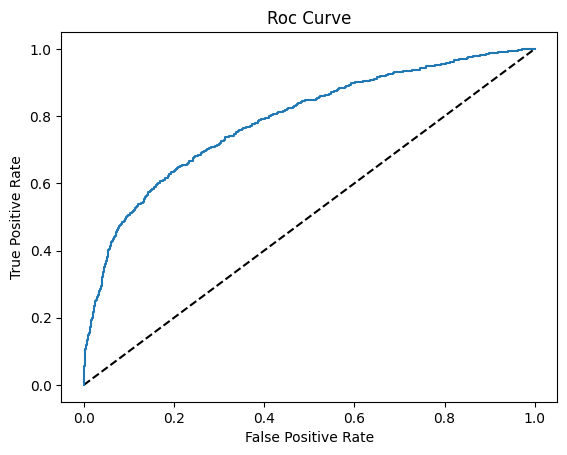

In [110]:
y_val_pred_NN = red_neuronal.predict(X_val_transf)

fpr, tpr, umbrales = roc_curve(y_val, y_val_pred_NN)

plt.plot([0,1],[0,1],'k--')
plt.plot(fpr,tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Roc Curve')
print(f'ROC AUC: {auc(fpr, tpr):.2f}')
plt.show()

## 5. Comparativa de los modelos

### Evaluación en el conjunto de validación

Recordemos que hemos ajustado los umbrales de decisión del XGBoost y la Red Neuronal buscando tener la misma sensibilidad en los tres modelos para así hacer una comparación mas acertada, es por esto que todos ellos tienen el mismo valor de 0.65 en Recall.

In [111]:
print('Regresión Logística\n',report_LR)
print('XGBoost\n',report_XGB)
print('Red Neuronal\n',report_red)

Regresión Logística
               precision    recall  f1-score   support

           0       0.94      0.77      0.85      4182
           1       0.27      0.65      0.38       556

    accuracy                           0.75      4738
   macro avg       0.61      0.71      0.61      4738
weighted avg       0.86      0.75      0.79      4738

XGBoost
               precision    recall  f1-score   support

           0       0.95      0.79      0.86      4182
           1       0.30      0.65      0.41       556

    accuracy                           0.78      4738
   macro avg       0.62      0.72      0.64      4738
weighted avg       0.87      0.78      0.81      4738

Red Neuronal
               precision    recall  f1-score   support

           0       0.94      0.79      0.86      4182
           1       0.29      0.64      0.40       556

    accuracy                           0.78      4738
   macro avg       0.62      0.72      0.63      4738
weighted avg       0.87      0

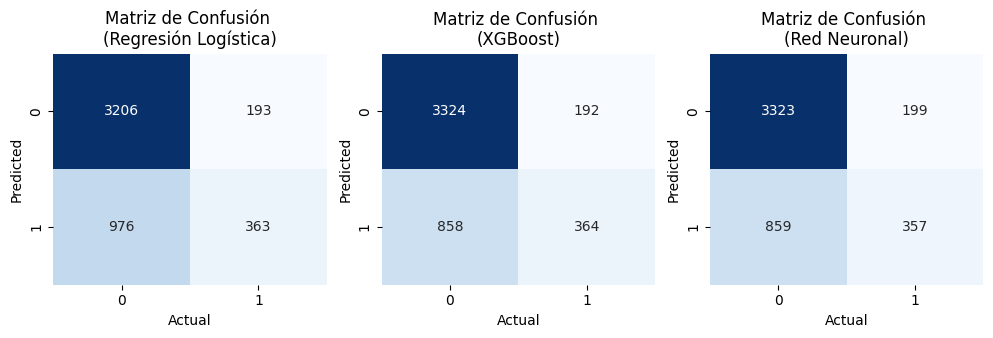

In [112]:
plt.figure(figsize=(12,3))

plt.subplot(1,3,1)
sns.heatmap(conf_matrix_LR, annot=True, cmap='Blues', fmt='d',cbar=False)
plt.title('Matriz de Confusión \n(Regresión Logística)')
plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.subplot(1,3,2)
sns.heatmap(conf_matrix_XGB, annot=True, cmap='Blues', fmt='d',cbar=False)
plt.title('Matriz de Confusión \n(XGBoost)')
plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.subplot(1,3,3)
sns.heatmap(conf_matrix_red, annot=True, cmap='Blues', fmt='d',cbar=False)
plt.title('Matriz de Confusión \n(Red Neuronal)')
plt.xlabel('Actual')
plt.ylabel('Predicted')

#plt.savefig('conf_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

Se observa que en este conjunto de datos tanto el XGBoost como la Red Neuronal tienen casi el mismo desempeño, el cual es ligeramente superior al de la regresión logística puesto que el número de falsos positivos es menor.

Sin embargo, a continuación haremos la prueba definitiva sobre el test-set.

### Evaluación en el conjunto de prueba

In [113]:
y_test_pred_LR = logistic_model.predict(X_test)
report_LR_test = classification_report(y_test,y_test_pred_LR)
conf_matrix_LR_test = confusion_matrix(y_test, y_test_pred_LR).T

y_test_pred_XGB = (xgboost.predict_proba(X_test)[:,1]>=umbral_XGB)*1
report_XGB_test = classification_report(y_test,y_test_pred_XGB)
conf_matrix_XGB_test = confusion_matrix(y_test, y_test_pred_XGB).T

y_test_pred_red = (red_neuronal.predict(X_test_transf)>=umbral_red)*1
report_red_test = classification_report(y_test,y_test_pred_red)
conf_matrix_red_test = confusion_matrix(y_test, y_test_pred_red).T

149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [114]:
print('Regresión Logística\n',report_LR_test)
print('XGBoost\n',report_XGB_test)
print('Red Neuronal\n',report_red_test)

Regresión Logística
               precision    recall  f1-score   support

           0       0.94      0.77      0.85      4182
           1       0.27      0.64      0.38       556

    accuracy                           0.75      4738
   macro avg       0.61      0.70      0.61      4738
weighted avg       0.86      0.75      0.79      4738

XGBoost
               precision    recall  f1-score   support

           0       0.95      0.81      0.87      4182
           1       0.32      0.67      0.43       556

    accuracy                           0.79      4738
   macro avg       0.63      0.74      0.65      4738
weighted avg       0.88      0.79      0.82      4738

Red Neuronal
               precision    recall  f1-score   support

           0       0.94      0.80      0.87      4182
           1       0.30      0.65      0.41       556

    accuracy                           0.78      4738
   macro avg       0.62      0.72      0.64      4738
weighted avg       0.87      0

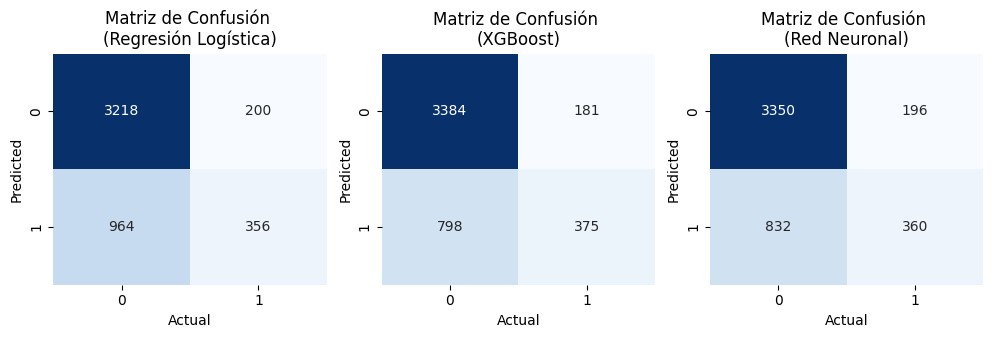

In [115]:
plt.figure(figsize=(12,3))

plt.subplot(1,3,1)
sns.heatmap(conf_matrix_LR_test, annot=True, cmap='Blues', fmt='d',cbar=False)
plt.title('Matriz de Confusión \n(Regresión Logística)')
plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.subplot(1,3,2)
sns.heatmap(conf_matrix_XGB_test, annot=True, cmap='Blues', fmt='d',cbar=False)
plt.title('Matriz de Confusión \n(XGBoost)')
plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.subplot(1,3,3)
sns.heatmap(conf_matrix_red_test, annot=True, cmap='Blues', fmt='d',cbar=False)
plt.title('Matriz de Confusión \n(Red Neuronal)')
plt.xlabel('Actual')
plt.ylabel('Predicted')

#plt.savefig('conf_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

Esto nos muestra que el modelo que mejor aprendió de los datos fue el **XGBoost**, presentando la mejor sensibilidad (0.67), identificando a 375 de 556  clientes interesados en adquirir el CDT, y lo hace a costa de un menor numero de falsos positivos en comparación a los otros dos modelos.

Es decir, mientras que el modelo de regresión logística nos permite identificar correctamente a 356 clientes interesados a costa de realizar 964 llamadas a clientes que no lo están; el XGBoost nos permite identificar más clientes interesados a un menor costo operativo.